# CS1090a Final Project Milestone 5

### Project  Title: Comparing Linear and Polynomial Models’ Ability to Predict Blood Lactate Levels with Metabolic and Biomechanical Indicators  

**Group Members:**

- David Soucie(sirob7007@gmail.com)

- Eva Harris (evaharris@college.harvard.edu)

- Ethan Aidam (eaidam@college.harvard.edu)

- Sam Burgess (sburgess@college.harvard.edu)

- Shay Li (sineadli@college.harvard.edu)


## Table of Contents
* [1 - Problem Statement](#1---problem-statement)

* [2 - Pre-Processing](#2---pre-processing)
    * [2.1 - Import Libraries](#21---import-libraries)
    * [2.2 - Data Loading](#22---data-loading)

* [3 - Data Description](#3---data-description)
    * [3.1 - Dataset Qualities](#31---dataset-qualities)
        * [3.1.1 - Combined Dataset](#311---combined-dataset)
        * [3.1.2 - By Individual Day](#312---by-individual-day)
        * [3.1.3 - Conclusions of Qualities Across Days](#313---conclusions-of-qualities-across-days)
    * [3.2 - Histograms](#32---histograms)
    * [3.3 - Correlation Plots](#33---correlation-plots)
        * [3.3.1 - Combined Dataset](#331---combined-dataset)
        * [3.3.2 - Individual Days](#332---individual-days)
    * [3.4 - Clustering Plots](#34---clustering-plots)
    * [3.5 - Findings Summary](#35---findings-summary)

* [4 - Baseline Model](#4---baseline-model)
    * [4.1 - Simple Linear Regression](#41---simple-linear-regression)
    * [4.2 - Multiple Linear Regression](#42---multiple-linear-regression)
    * [4.3 - Model with Interaction Terms](#43---model-with-interaction-terms)
    * [4.4 - Polynomial Term (squared terms)](#44---polynomial-term-squared-terms)
    * [4.5 - Model Selection Comparison](#45---model-selection-comparison)
        * [4.5.1 - Assumption Checking for Linear Models](#451---assumption-checking-for-linear-models)

* [5 - Prediction Models](#5---prediction-models)
    * [5.1 - Baseline Predictive Model](#51---baseline-predictive-model)
    * [5.2 - LASSO Regression](#52---lasso-regression)
    * [5.3 - RIDGE Regression](#53---ridge-regression)
    * [5.4 - Random Forest](#54---random-forest)


## 1 - Problem Statement

**Motivation:** Understanding the factors influencing blood lactate threshold is vital for assessing athletic performance and designing personalized training. Our project explores the usage of models to capture trends in blood lactate across exercise intensities. Since blood lactate test generally require blood samples, it generally is an added cost for elite athletic teams. If a model were to accurately predict lactate from data, testing could be done on a less-frequent basis. Thus, reducing costs and saving time for elite athletes. 

 We have **two main goals** for which we are attempting to evaluate the models:

    - How well do models predict the current Blood Lactate level, given several other easier to measure features?

    - How well do models predict a future Blood Lactate level, based on other easier to measure features?


The **overall goal** of these evaluations is to determine whether future methods for predicting blood lactate, both in the present and future, should presume a linear or non-linear relationship between the predictors and target. At the moment, we hypothesize that traditional linear models may oversimplify the nonlinear relationships between biomechanical variables (e.g., cadence) and metabolic measures ($VO_2$ max, heart rate). We are evaluating our conclusion such that if the best performing model is linear, a linear relationship can be determined. Likewise if the best performing model is polynomial, a non-linear relationship can be determined. Best performance will be measured using $R^2$.

**Import Libraries**

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from scipy import stats
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [102]:
# pandas tricks for better display
pd.options.display.max_columns = 50  
pd.options.display.max_rows = 500     
pd.options.display.max_colwidth = 100
pd.options.display.precision = 3

## 2 - Data Description

We will use a dataset from Kaggle titled ["Cycling[La]: Blood Lactate Concentration During Cycling High Intensity Interval Training"](https://www.kaggle.com/datasets/andreazignoli/cycling-la/). 


This data was collected from a single high performance athlete being tested for $VO_2$ maximum using an indoor cycler across 3 days of testing, using various wearable devices and monitors. Each test involved the exact same workout: a combination of low intensity baseline activity with specific periods of high intensity exercise.


The data was entirely complete, with no null values. Most values are floats, though a few values are integers; all are numeric. Each row of the dataset is a specific second of the training session, and each feature is a biometric observation specific to that second.


Our processed dataset includes the following 9 features, all of which with 8818 entries:

| Feature      | Description                                                    | Units / Notes      |
| ------------ | -------------------------------------------------------------- | ------------------ |
| `time`       | Second of the test when the measurement was taken              | seconds            |
| `power`      | Cycling power output                                           | watts              |
| `VO2`        | Oxygen consumption                                             | O₂/min             |
| `cadence`    | Cycling cadence (revolutions per minute)                       | RPM                |
| `lactate`    | Blood lactate concentration                                    | mmol/L             |
| `rf`         | Respiratory frequency                                          | breaths per minute |
| `heart_rate` | Heart rate                                                     | beats per minute   |
| `saturation` | Blood oxygen saturation                                        | percentage (%)     |
| `day`        | Day on which the data was collected (pre-processing indicator) | 1, 2, or 3         |


## 3 - Processing / EDA

**Data Loading**

In order to evaluate whether the data behaves differently across days of training, we consider 4 datasets in total. First, we loaded data from each of the three days from the Kaggle, and named them `day[n]_df`, for $n \in [1, 3]$ accordingly. Each dataframe correspondes to the associated day of the training session. Then, we concatenated all three datasets into one overall dataset titled `day_all_lactate_challenge.csv`, and added a new column of "Day" so we could recognize the day that any specific row's observation was taken. For simplicity, our overall dataset is denoted as `df` through this notebook.

In [103]:
kaggle_day1_df = pd.read_csv("data/day1_lactate_challenge.csv")
kaggle_day2_df = pd.read_csv("data/day2_lactate_challenge.csv")
kaggle_day3_df = pd.read_csv("data/day3_lactate_challenge.csv")

kaggle_day1_df["day"] = 1
kaggle_day2_df["day"] = 2
kaggle_day3_df["day"] = 3

df = pd.concat([kaggle_day1_df, kaggle_day2_df, kaggle_day3_df], ignore_index=True)
df.to_csv('data/day_all_lactate_challenge.csv', index=False)
df.head()

,time,power,VO2,cadence,lactate,rf,heart_rate,saturation,day
0,1,0,313.460,0,0.749,18.445,52.5,99.0,1
1,2,0,214.150,0,0.748,17.962,53.0,99.0,1
2,3,0,114.840,0,0.747,17.480,53.5,99.0,1
3,4,0,15.532,0,0.746,16.997,54.0,99.0,1
4,5,0,247.580,0,0.745,16.748,54.0,99.0,1


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8818 entries, 0 to 8817
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time        8818 non-null   int64  
 1   power       8818 non-null   int64  
 2   VO2         8818 non-null   float64
 3   cadence     8818 non-null   int64  
 4   lactate     8818 non-null   float64
 5   rf          8818 non-null   float64
 6   heart_rate  8818 non-null   float64
 7   saturation  8818 non-null   float64
 8   day         8818 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 620.1 KB



We noticed that in calling `df.head`, there are 0's in `power` and `cadence`. This is strange. Additionally the `Non-Null Count` from `.info()` tells us that we have no null values. We will further parse the qualities of each individual day to see if there are 0's across  `power` and `cadence` among all three days or if it simply was not recorded on that day. 

### 3.1 - Qualities by Day

**Dataset Qualities**

The qualities used to analyze the dataset are:

| Statistic          | Description                                                      |
| ------------------ | ---------------------------------------------------------------- |
| Mean               | Mean (average) value of all observations in the column           |
| Standard Deviation | Standard deviation of all observations in the column             |
| Maximum            | Maximum value observed in the column                             |
| Minimum            | Minimum value observed in the column                             |
| Outliers           | Number of observations with an absolute z-score greater than 2.5 |

^*We created a helper function defined as `calc_outliers`, which is designed to calculate the numner of outliers present in each feature. Our `Outliers` count was determined based upon z-score.*



In [105]:
# Function takes in a dataframe, then outputs a tall dataframe with a single column containing the outlier count for each column of the inputted dataframe, and each row representing a column of the inputted dataframe
def calc_outliers(in_df):
    output = pd.DataFrame()
    for column in in_df.columns:
        z_score = np.abs(stats.zscore(in_df[column]))
        output[column] = [in_df[z_score > 2.5][column].count()]
    return pd.melt(output, value_vars = in_df.columns, var_name = "index", value_name = "Outliers").set_index("index")

#### 3.1.2 - By Individual Day

Next, we decided to parse the individual days to get a picture regarding the data in each day. We are selecting into each day from our concatanted dataset, since this is the dataset we are focused on processing. By analyzing each day individually, we can better understand the variation between the days and how this may affect our analysis later in this notebook.


**Day 1**

In [106]:
# Day 1 Qualities
df_day1 = df.loc[df["day"] == 1]

pd.DataFrame({"Null count": df_day1.isnull().sum(),
              "Mean": df_day1.mean(),
              "Standard Deviation": df_day1.std(),
              "Maximum": df_day1.max(),
              "Minimum": df_day1.min(),
              "Outliers": [val[0] for val in calc_outliers(df_day1).values]})


C:\Users\sburg\AppData\Local\Temp\ipykernel_13820\1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1619.500,934.874,3238.000,1.000,0
power,0,129.608,97.694,350.000,0.000,0
VO2,0,2140.876,1034.657,4788.300,15.532,2
cadence,0,70.748,41.793,112.000,0.000,0
lactate,0,4.593,2.865,9.790,0.630,0
rf,0,24.898,6.376,75.483,6.920,85
heart_rate,0,121.027,31.156,177.000,49.000,0
saturation,0,96.981,1.352,99.000,94.000,0
day,0,1.000,0.000,1.000,1.000,0


We know from calling `df.head()` earlier that some values in Day 1 are 0's. However, in this chart, we can see that the mean of `cadence` and `power` are non-zero. This means that we have 0's intermixed with non-zero data. I will now explore these 0's further to decide whether they occur due to a collection error or are an aspect of the data. 



Assuming they are not a collection error, I have to think that the athlete was resting rather than actively biking. Given this, it would make sense to see their heart rate (and maybe their lactate) drop at the same time. To explore this, I will be using trace plots. 

The first trace plot I will create is a plot of lactate versus time. I will use a binary indicator to show me when both `power` and `cadence` are zero (Indicator=0) versus non-zero (Indicator=1). I will then plot this indicator againt time, just like my previous plot. In my final trace plot, I will plot heart `heart_rate` versus time. 

Based on my personal experience with heart rate and lactate, heart rate will drop sharply, and lactate will follow at a slower rate if the athlete is at rest. 

In [107]:
df1 = df_day1.copy()

# Indicator: both power and cadence are zero
df1["zero_both"] = (df1["power"] == 0) & (df1["cadence"] == 0.0)
df1["zero_label"] = df1["zero_both"].map({True: "Power & Cadence = 0",
                                          False: "Power & Cadence > 0"})

# Bin time into quartiles for boxplots "with respect to time"
df1["time_bin"] = pd.qcut(df1["time"], q=4,
                          labels=["Early (Q1)", "Q2", "Q3", "Late (Q4)"])

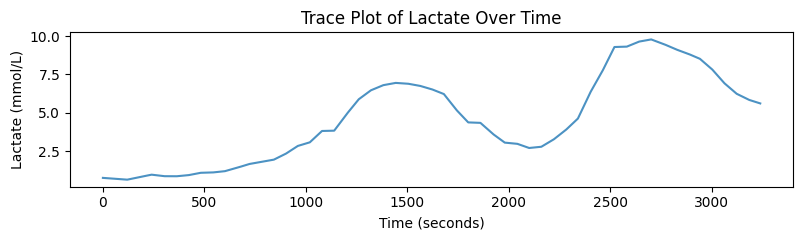

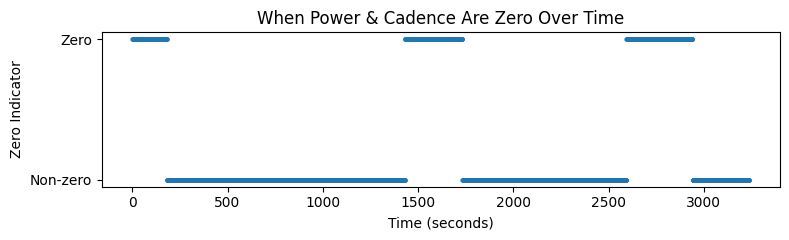

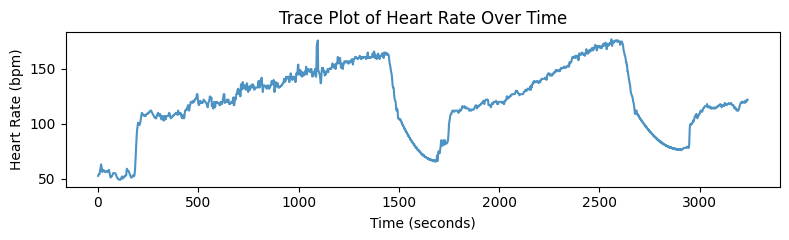

In [108]:
# trace plots

# Lactate vs Time
# Trace plot of lactate over continuous time
plt.figure(figsize=(8, 2.5))
plt.plot(df1["time"], df1["lactate"], alpha=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Lactate (mmol/L)")
plt.title("Trace Plot of Lactate Over Time")
plt.tight_layout()
plt.show()


# Zeros vs Non-Zeros with respect to Time
# Trace plot: binary indicator of zero vs non-zero over time
plt.figure(figsize=(8, 2.5))
plt.scatter(df1["time"],
            df1["zero_both"].astype(int),
            s=5, alpha=0.8)
plt.yticks([0, 1], ["Non-zero", "Zero"])
plt.xlabel("Time (seconds)")
plt.ylabel("Zero Indicator")
plt.title("When Power & Cadence Are Zero Over Time")
plt.tight_layout()
plt.show()


# Heart Rate vs Time
# Trace plot of heart rate over time
plt.figure(figsize=(8, 2.5))
plt.plot(df1["time"], df1["heart_rate"], alpha=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Trace Plot of Heart Rate Over Time")
plt.tight_layout()
plt.show()


Our indicator variable lines up perfectly with drops in `heart_rate` and `lactate`! This confirms that when `power = 0` and `cadence = 0`, the athlete is at rest. 

Now I want to check whether `power` and `cadence` will always = 0 at the same time.  


In [109]:
# Rows where power == 0 but cadence != 0
power_zero_cadence_nonzero = df[(df["power"] == 0) & (df["cadence"] != 0.0)]

# Rows where cadence == 0 but power != 0
cadence_zero_power_nonzero = df[(df["cadence"] == 0.0) & (df["power"] != 0)]

len(power_zero_cadence_nonzero), len(cadence_zero_power_nonzero)


(0, 5)

There are no instances in which `power` = 0 but `cadence` is not equal to 0. However, we have **five** instances (in the concatenated dataset, so across all three days) in which `cadence` drops off before `power` does. I  decided to print out the five values in `cadence_zero_power_nonzero` below.

In [110]:
print(cadence_zero_power_nonzero[["time", "power", "cadence", "day"]])

      time  power  cadence  day
181    182    100        0    1
1732  1733     93        0    1
2940  2941     98        0    1
2941  2942     99        0    1
3418   181     98        0    2


I'm not an avid cyclist, however, it would make sense that `cadence` drops before `power` registers zero or that the flywheel still produces power momentarily after the biker has stopped pedaling. The trace plot that plotted `heart_rate` against `time` from earlier appeared to be most aligned with the motions of the athlete, so let's add the points from  `cadence_zero_power_nonzero` see if this confirms our logic.

It appears that **four** of the points are in day 1, so I will use the same `df1` I used for the previous trace plots. These **four** points should be able to give us intuition for the pattern of where this occurs. (note the graph below looks like **three** points because the points at `time` = 2941 and `time` = 2942 seconds have overlapped)

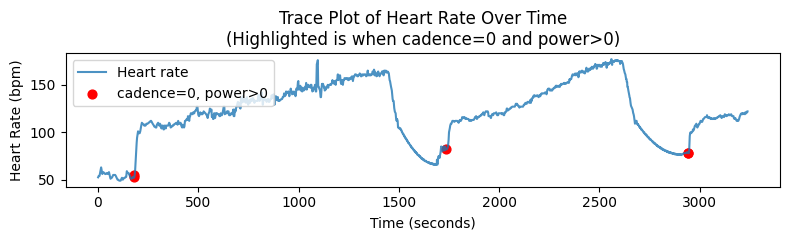

In [111]:
# Heart Rate vs Time (with marks on cadence_zero_power_nonzero)
plt.figure(figsize=(8, 2.5))
plt.plot(df1["time"], df1["heart_rate"], alpha=0.8, label="Heart rate")
plt.scatter(
    cadence_zero_power_nonzero["time"],
    cadence_zero_power_nonzero["heart_rate"],
    color="red",
    s=40,
    label="cadence=0, power>0"
)
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Trace Plot of Heart Rate Over Time\n(Highlighted is when cadence=0 and power>0)")
plt.legend()
plt.tight_layout()
plt.show()

This is really interesting. Contrary to what we thought, it appears that `cadence_zero_power_nonzero` only actually occcurs when the biker is starting to pedal again.

As a part of our preprocessing, I will create a new column such that it only contains nonzero values of power and cadence. This will help us later compare active riding versus the full session. I will also print our `Qualities` chart again to reflect the changes. 

**QUESTION: Are null values okay in this instance? We should probably consider dropping the power values in which cadence = 0 since the biker technically is not riding the bike.**

In [112]:
df["cadence_nonzero"] = df["cadence"].where(df["cadence"] > 0)
df["power_nonzero"]= df["power"].where(df["power"] > 0)

# Day 1 Qualities (V2)
df_day1 = df.loc[df["day"] == 1]

pd.DataFrame({"Null count": df_day1.isnull().sum(),
              "Mean": df_day1.mean(),
              "Standard Deviation": df_day1.std(),
              "Maximum": df_day1.max(),
              "Minimum": df_day1.min(),
              "Outliers": [val[0] for val in calc_outliers(df_day1).values]})

C:\Users\sburg\AppData\Local\Temp\ipykernel_13820\1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1619.500,934.874,3238.000,1.000,0
power,0,129.608,97.694,350.000,0.000,0
VO2,0,2140.876,1034.657,4788.300,15.532,2
cadence,0,70.748,41.793,112.000,0.000,0
lactate,0,4.593,2.865,9.790,0.630,0
rf,0,24.898,6.376,75.483,6.920,85
heart_rate,0,121.027,31.156,177.000,49.000,0
saturation,0,96.981,1.352,99.000,94.000,0
day,0,1.000,0.000,1.000,1.000,0
cadence_nonzero,833,95.253,4.099,112.000,52.000,0


**Day 2**

In [113]:
# Day 2 Qualities

#drawing from our combined dataset for consistency
df_day2 = df.loc[df["day"] == 2]

pd.DataFrame({"Null count" : df_day2.isnull().sum(),
              "Mean" : df_day2.mean(), 
              "Standard Deviation" : df_day2.std(), 
              "Maximum" : df_day2.max(), 
              "Minimum" : df_day2.min(),
             "Outliers": [val[0] for val in calc_outliers(df_day2).values]})

C:\Users\sburg\AppData\Local\Temp\ipykernel_13820\1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1590.500,918.131,3180.000,1.000,0
power,0,145.148,111.674,596.000,0.000,57
VO2,0,2493.999,939.473,4869.200,15.086,25
cadence,0,80.304,35.378,145.000,0.000,0
lactate,0,4.399,2.180,7.630,0.580,0
rf,0,27.894,6.684,56.075,4.481,70
heart_rate,0,123.464,26.770,166.000,51.000,125
saturation,0,95.436,1.478,99.000,91.000,1
day,0,2.000,0.000,2.000,2.000,0
cadence_nonzero,506,95.500,6.063,145.000,29.000,0


Following from our analysis on day1, it makes sence that day2 has a minimum power and cadence of 0 because when we explored `cadence_zero_power_nonzero`, we found an occurance in day 2 as well. Everything else looks normal. I will explore how each feature behaves against time in the section about the combined dataset.

**Day 3**

In [114]:
# Day 3 Qualities

#drawing from our combined dataset for consistency
df_day3 = df.loc[df["day"] == 3]


pd.DataFrame({"Null count" : df_day3.isnull().sum(),
              "Mean" : df_day3.mean(), 
              "Standard Deviation" : df_day3.std(), 
              "Maximum" : df_day3.max(), 
              "Minimum" : df_day3.min(),
              "Outliers": [val[0] for val in calc_outliers(df_day3).values]})

C:\Users\sburg\AppData\Local\Temp\ipykernel_13820\1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1200.500,692.965,2400.000,1.000,0
power,0,112.067,131.468,778.000,0.000,123
VO2,0,2273.196,1038.358,4561.700,2.415,0
cadence,0,76.800,41.585,170.000,0.000,0
lactate,0,7.564,3.708,11.160,0.610,0
rf,0,28.701,8.953,63.158,9.624,40
heart_rate,0,115.822,30.254,161.000,48.000,0
saturation,0,97.044,1.593,99.000,93.000,13
day,0,3.000,0.000,3.000,3.000,0
cadence_nonzero,496,96.807,15.565,170.000,66.000,0


Following from our analysis on day1, it makes sence that day2 has a minimum power and cedence of 0 because when we explored `cadence_zero_power_nonzero`, we found an occurance in day 2 as well. Everything else looks normal. I will explore how each feature behaves against time in the section about the combined dataset.

**QUESTION: when I printed the values in which cadence and power = 0, there were no instances in day 3. Why does day3 still have a minimum of 0 for both cadence and power?**

#### 3.1.2 - Combined Dataset

**Qualities**

In [115]:
pd.DataFrame({"Null count" : df.isnull().sum(), 
              "Mean" : df.mean(), 
              "Standard Deviation" : df.std(), 
              "Maximum" : df.max(), 
              "Minimum" : df.min(),
              "Outliers": [val[0] for val in calc_outliers(df).values]})

,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1495.002,887.722,3238.000,1.000,0
power,0,130.438,113.461,778.000,0.000,184
VO2,0,2304.235,1013.736,4869.200,2.415,1
cadence,0,75.841,39.749,170.000,0.000,0
lactate,0,5.332,3.215,11.160,0.580,0
rf,0,27.014,7.453,75.483,4.481,181
heart_rate,0,120.489,29.547,177.000,48.000,0
saturation,0,96.441,1.649,99.000,91.000,17
day,0,1.905,0.794,3.000,1.000,0
cadence_nonzero,1835,95.771,9.290,170.000,29.000,0


#### 3.1.3 - Conclusions of Qualities Analysis

Some variation can be seen in the mean and standard deviation of each field on a per-day basis. However, unless these differences are also reflected in the correlations for each feature, it should not affect the results significantly.

What could more significantly affect results is the high discrepency between mean, variance, and standard deviation between the different features, as well as a number of outliers within the data. Since our testing will go on to include polynomial regression at higher orders, scaling will be needed to prevent numerical instability. 


### 3.2 - All Feature Trace Plots

Overall, we want to look at how the features change over time, split by days. Thus, we wrote a function plot_trace_feature to display trace plots for each feature over time, split by days.

In [116]:
def plot_trace_feature(feature):
    fig, axes = plt.subplots(1, 3, figsize=(24, 2.5))

    # Day 1
    axes[0].plot(df_day1["time"], df_day1[feature], alpha=0.8)
    axes[0].set_xlabel("Time (seconds)")
    axes[0].set_ylabel(feature)
    axes[0].set_title(f"Day 1: Trace Plot of {feature} Over Time")

    # Day 2
    axes[1].plot(df_day2["time"], df_day2[feature], alpha=0.8)
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel(feature)
    axes[1].set_title(f"Day 2: Trace Plot of {feature} Over Time")

    # Day 3
    axes[2].plot(df_day3["time"], df_day3[feature], alpha=0.8)
    axes[2].set_xlabel("Time (seconds)")
    axes[2].set_ylabel(feature)
    axes[2].set_title(f"Day 3: Trace Plot of {feature} Over Time")

    plt.tight_layout()
    plt.show()

#### 3.2.1 - Mechanical Output

These features pertain to how the athlete performed physically.

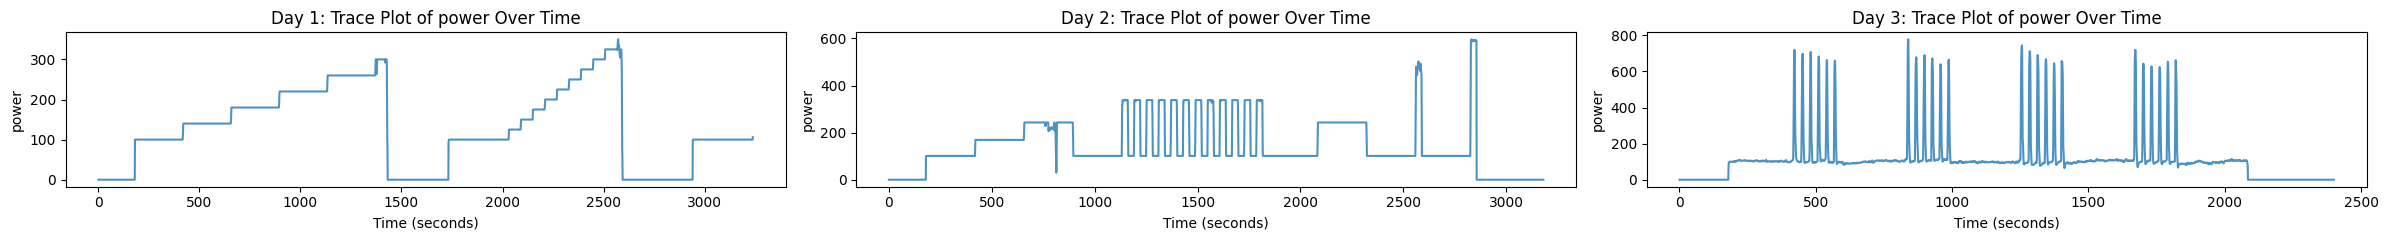

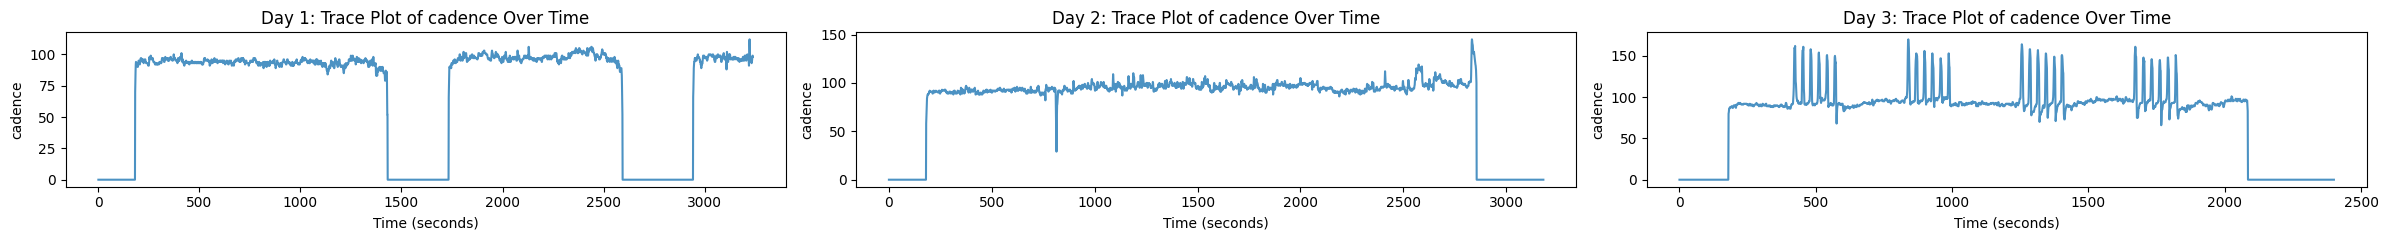

In [117]:
for feat in ["power", "cadence"]:
    plot_trace_feature(feat)

The trace plots for power and cadence look noticeably different on Day 3 compared to Days 1 and 2. Day 3 has lots of short, sharp bursts where the athlete suddenly pushes very hard.

#### 3.2.2 - Metabolism

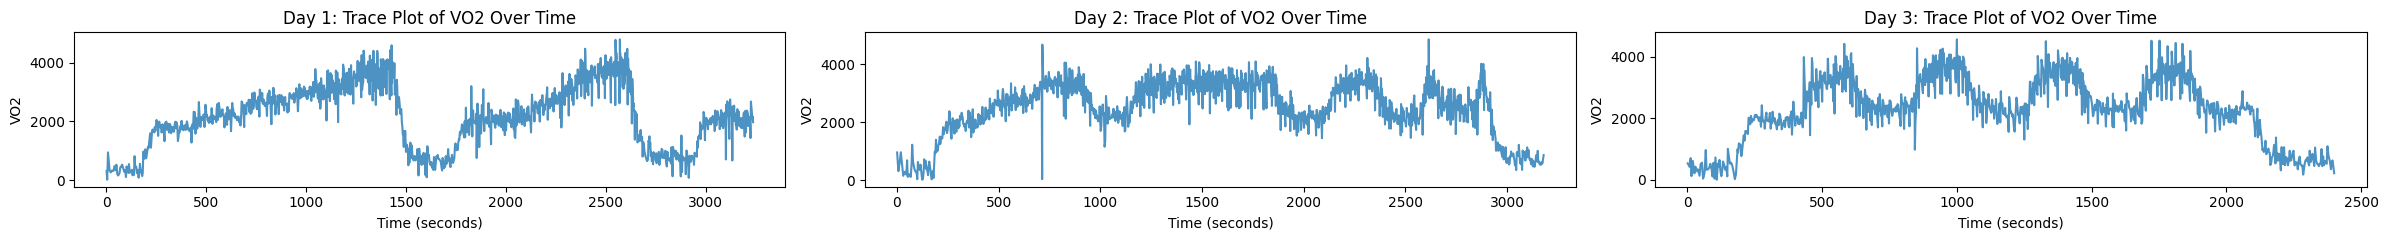

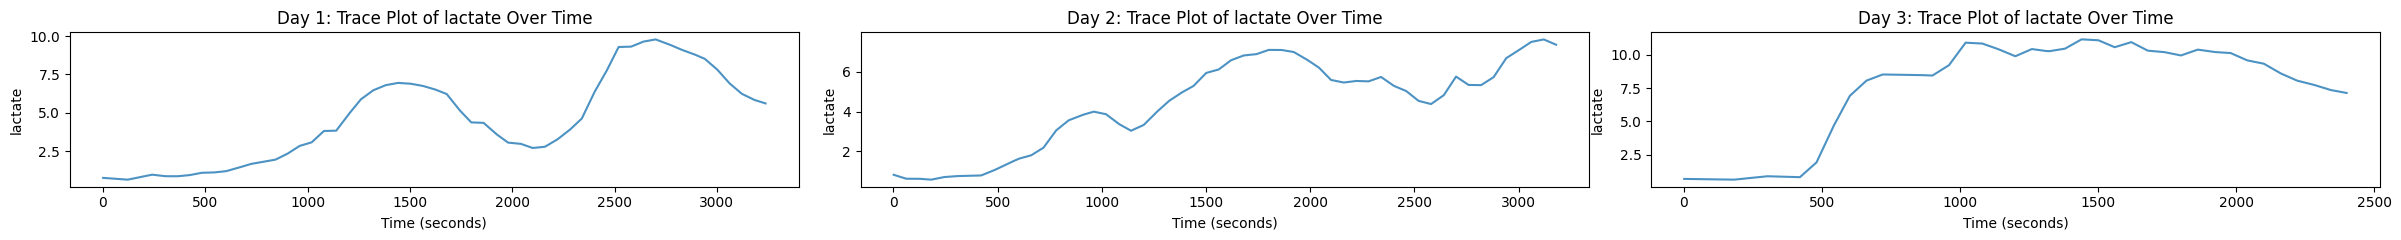

In [118]:
for feat in ["VO2", "lactate"]:
    plot_trace_feature(feat)

#### 3.2.3 - Cardio Response

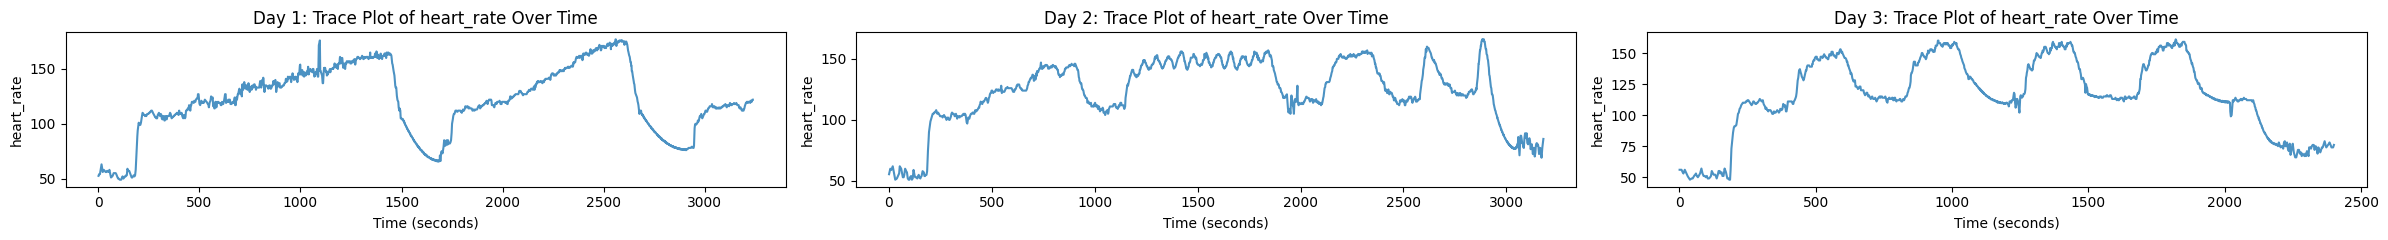

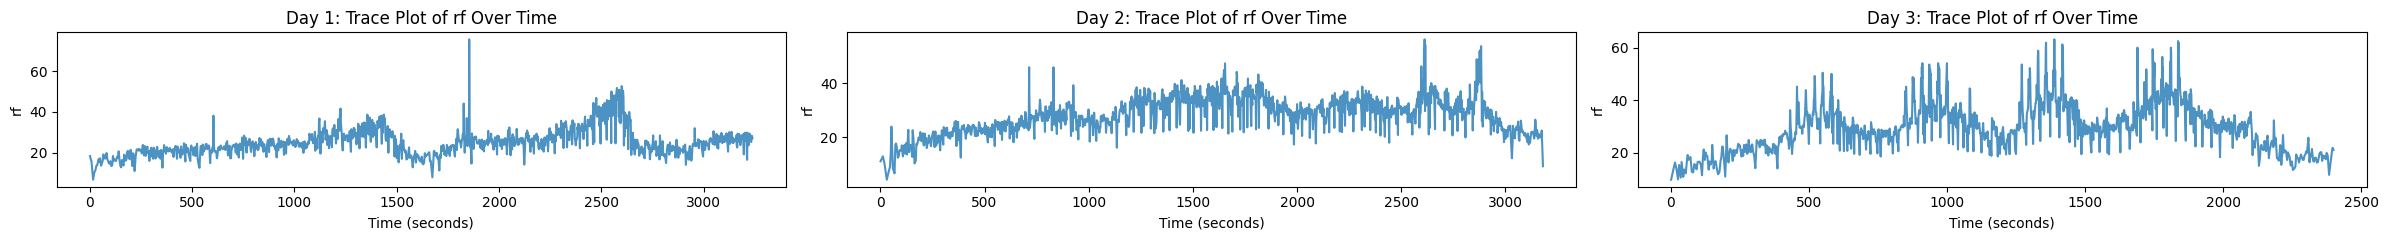

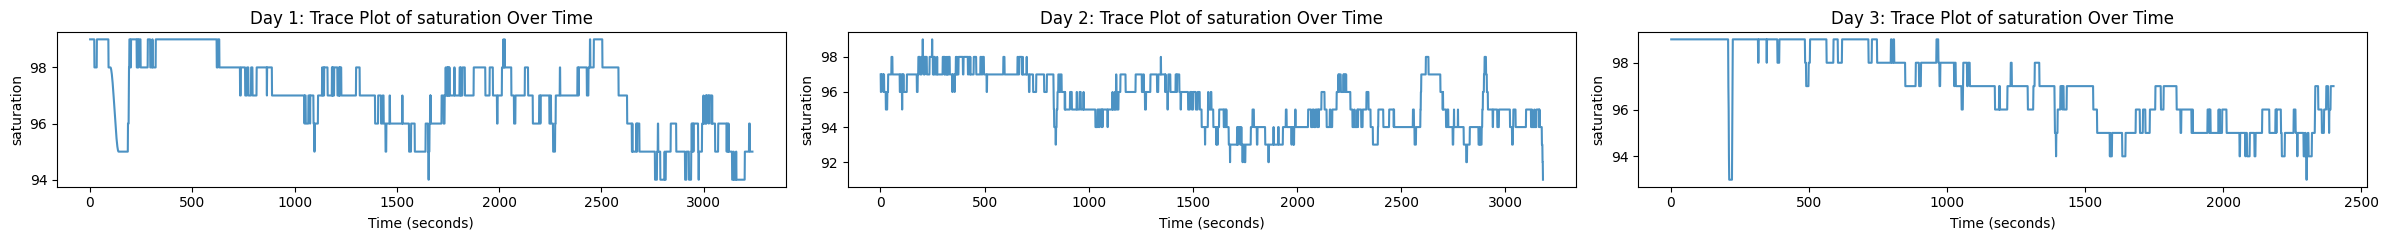

In [119]:
for feat in ["heart_rate", "rf", "saturation"]:
    plot_trace_feature(feat)

The athlete held a similar power and cadence level for the majority of the test, but with occasional bursts of higher levels of power and speed. This matches the typical process for VO2 max testing, with a default steady pace followed by bursts of max effort at specific intervals. 

`Saturation` does not have any float values, which is why it appears to jump around more.

**DO: Analyze trace plots and compare non_zero plots to normal plots**

**DO: scale the numerical predictors and OneHotEncode Categorical Var (day)**



### 3.4 - All Feature Histograms

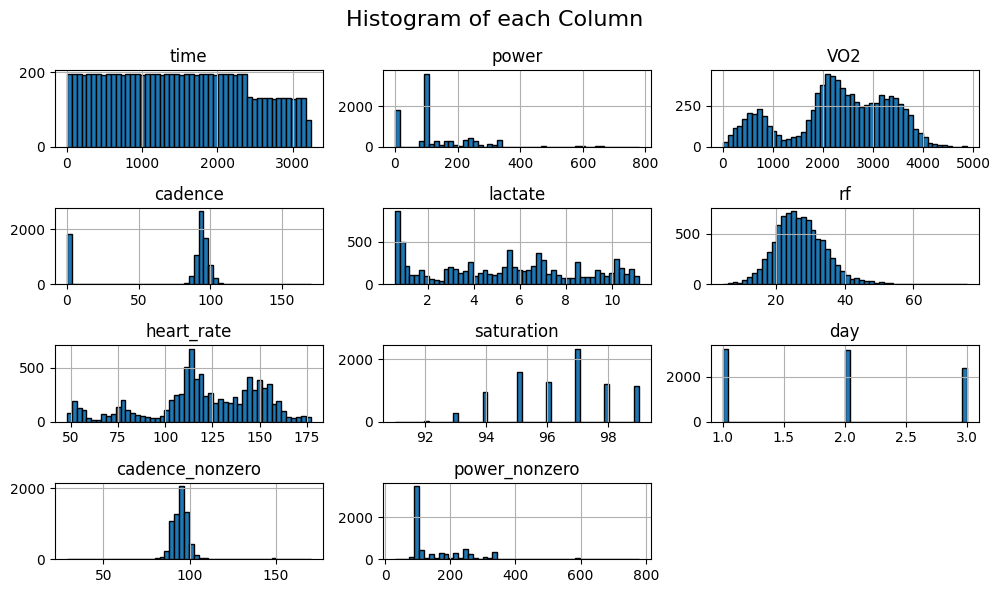

In [120]:
df.hist(figsize=(10, 6), bins = 50, edgecolor = "black")

plt.suptitle("Histogram of each Column", fontsize = 16)
plt.tight_layout()
plt.show()

No noteworthy concerns from the histogram, though some features do give insight on the nature of the performance. Notably, time distribution shows that each session did not have the exact same total training time, since certain time values are less represented than others. Day 3 appears to have less observation than Day 2 and Day 1. 

### 3.5 - Correlation Plots

([<matplotlib.axis.YTick at 0x1e90604cf10>,
 [Text(0, 0, 'time'),
  Text(0, 1, 'power'),
  Text(0, 2, 'VO2'),
  Text(0, 3, 'cadence'),
  Text(0, 4, 'lactate'),
  Text(0, 5, 'rf'),
  Text(0, 6, 'heart_rate'),
  Text(0, 7, 'saturation'),
  Text(0, 8, 'day'),
  Text(0, 9, 'cadence_nonzero'),
  Text(0, 10, 'power_nonzero')])

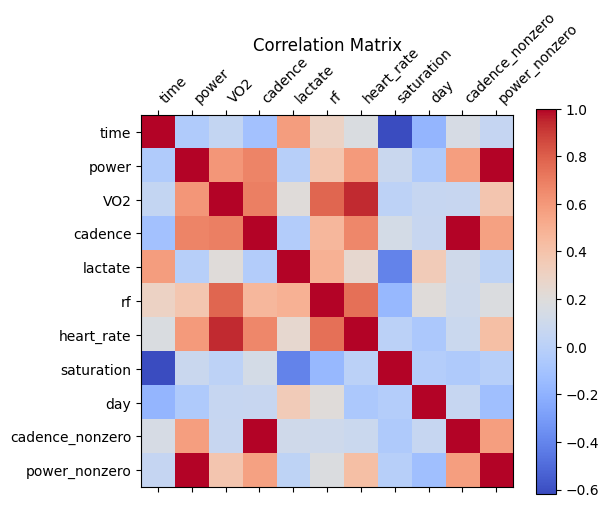

In [121]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr, cmap="coolwarm")

plt.title("Correlation Matrix", y=1.15)
plt.colorbar(cax)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="left")
plt.yticks(range(len(corr.columns)), corr.columns)

#### 3.5.1 - Combined Dataset

In [122]:
# Takes in an input of a correlation matrix, and returns a dataset that 
# neatly displays every single correlation, sorted from highest correlated 
# interaction to lowest.
#      - no self-correlations (corr(x, x))
#      - no duplicate symmetric pairs (corr(x, y) and corr(y, x))
def display_corr_total(corr):
    corr_flat = (
        corr.unstack()
             .reset_index()
             .rename(columns={'level_0': 'Variable 1',
                              'level_1': 'Variable 2',
                              0: 'Correlation'})
    )
    corr_flat = corr_flat[corr_flat['Variable 1'] != corr_flat['Variable 2']]
    corr_flat = corr_flat.drop_duplicates(subset=['Correlation'])
    
    corr_flat = corr_flat.sort_values(by='Correlation', ascending=False)
    return corr_flat

display_corr_total(corr)



,Variable 1,Variable 2,Correlation
21,power,power_nonzero,1.000
28,VO2,heart_rate,0.938
27,VO2,rf,0.779
61,rf,heart_rate,0.745
25,VO2,cadence,0.694
14,power,cadence,0.672
39,cadence,heart_rate,0.664
13,power,VO2,0.603
17,power,heart_rate,0.594
4,time,lactate,0.581


By standard machine learning practice, I will now use a threshold correlation of $0.8$ to capture potential multicollinearity. 

In [123]:
def display_corr_pairs(corr, threshold=0.8):
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # keep upper triangle only
            .stack()
            .reset_index()
    )
    corr_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    corr_pairs = corr_pairs.loc[corr_pairs["Correlation"].abs() > threshold]
    corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)
    
    return corr_pairs

display_corr_pairs(corr)

,Variable 1,Variable 2,Correlation
18,power,power_nonzero,1.000
32,cadence,cadence_nonzero,1.000
22,VO2,heart_rate,0.938


The above printed correlation plots tell us that `heart_rate` and `VO2` are most highly correlated. The have a calculated correlation of 0.938. Because `heart_rate` is generally a far more accessible metric to calcuate than `VO2`, we will be dropping `VO2`.

**QUESTION: how to handle corr btwn power and power_nonzero**

In [124]:
df = df.drop(columns=["VO2"])

#### 3.5.2 - By Individual Day

We will now consider how the correlations change through the days of training. Below, I have maintained the threshold correlation of $0.8$ to capture potential multicollinearity and have printed the relevant correlations so we can analyze them.

**Day 1**

In [125]:
#to reflect update of dropping VO2
df_day1 = df.loc[df["day"] == 1]

display_corr_pairs(df_day1.corr())

,Variable 1,Variable 2,Correlation
14,power,power_nonzero,1.000
19,cadence,cadence_nonzero,1.000
32,heart_rate,power_nonzero,0.937
11,power,heart_rate,0.825
2,time,lactate,0.807


Interpretation:

- `lactate` x `time`: I don't think we do anything about this because lactate is our predictor and time tells us the flow of our data through the lactate test

- `power` x `heart_rate`: This is interesting, but all it means is that when the power output goes up, the athlete's heart rate tends to rise, so it is expected. However, this correlation did not come up when analyzing our overall df so I want to see how it changes throught the days. The nice thing about power and cadence is that they are both better suited for understanding whether the athlete is actively in the piece or at rest, but if heart_rate can tell us the same info then it makes sense to drop them as we go to fit more advanced models.

- `power_nonzero` x `heart_rate`: See above. Depending on circumstance and what we are looking for explore, use power_nonzero or just power. But never both.

- `cadence` x `cadence_nonzero`, `power` x `power_nonzero`: Depending on circumstance and what we are looking for explore, use one or the other. But never both.

^**Note, when I move forward to analyze day 2 and day 3, I will be ignoring the correlation between `cadence` x `cadence_nonzero` and `power` x `power_nonzero` for the take of brevity.**

As mentioned previously, depending on circumstance and what we are looking for explore, we will use one or the other. But never both. Please note that we drop the _nonzero versions following conclusions derived from fitting our first round of simple linear regressions (Section 4.1). We give an appropriate breakdown of the logic behind doing this in the associated section (Section 4.1).

**Day 2**

In [126]:
#to reflect update of dropping VO2
df_day2 = df.loc[df["day"] == 2]

display_corr_pairs(df_day2.corr())

,Variable 1,Variable 2,Correlation
14,power,power_nonzero,1.000
19,cadence,cadence_nonzero,1.000
2,time,lactate,0.848


Comparisons:

- `power` x `heart_rate` is no longer meeting the threshold in Day 2 (met the threshold in Day 1). 

- `lactate` x `time` now meets the threshold (did not meet the threshold in Day 1).


**Day 3**

In [127]:
#to reflect update of dropping VO2
df_day3 = df.loc[df["day"] == 3]

display_corr_pairs(df_day3.corr())


,Variable 1,Variable 2,Correlation
14,power,power_nonzero,1.000
19,cadence,cadence_nonzero,1.000
13,power,cadence_nonzero,0.919
35,cadence_nonzero,power_nonzero,0.919
20,cadence,power_nonzero,0.919
26,rf,heart_rate,0.820
5,time,saturation,-0.852


Comparisons:

- `power` x `heart_rate` is no longer meeting the threshold in Day 3 (met the threshold in Day 1). 

- `lactate` x `time` still meets the threshold (met the threshold in Day 2 but not Day 1).

- `saturation` x `time` is a new correlation that is only present in Day 3.

- `heart_rate` x `rf` is a new correlation that is only present in Day 3.


Via the correlation matrix, we can see a few notably strong correlations, those being VO2 with heart rate and respiration, respiration with heart rate, and VO2 with cadence. A relatively strong negative correlation can also be seen with time and saturation.

We can also see significant variation in the correlations between specific features, even though no significant correlations between the specific day and each feature can be seen. This suggests that the athlete may have different performance circumstances across the training session of each day in the dataset, potentially due to factors like sleep, fatigue, and lifestyle influence, all of which lack metrics in this dataset.
No signfi

Regardless, no significant correlations between the specific day and each feature can be seen. For this reason, a model trained using a dataset of the entire test set can be trusted to be reasonably accurate depiction of predictive ability, so long as it doesn't perform significantly weaker on any one day of the test or has large variance in its predictive performance across days. 

### 3.6 - Clustering Plots

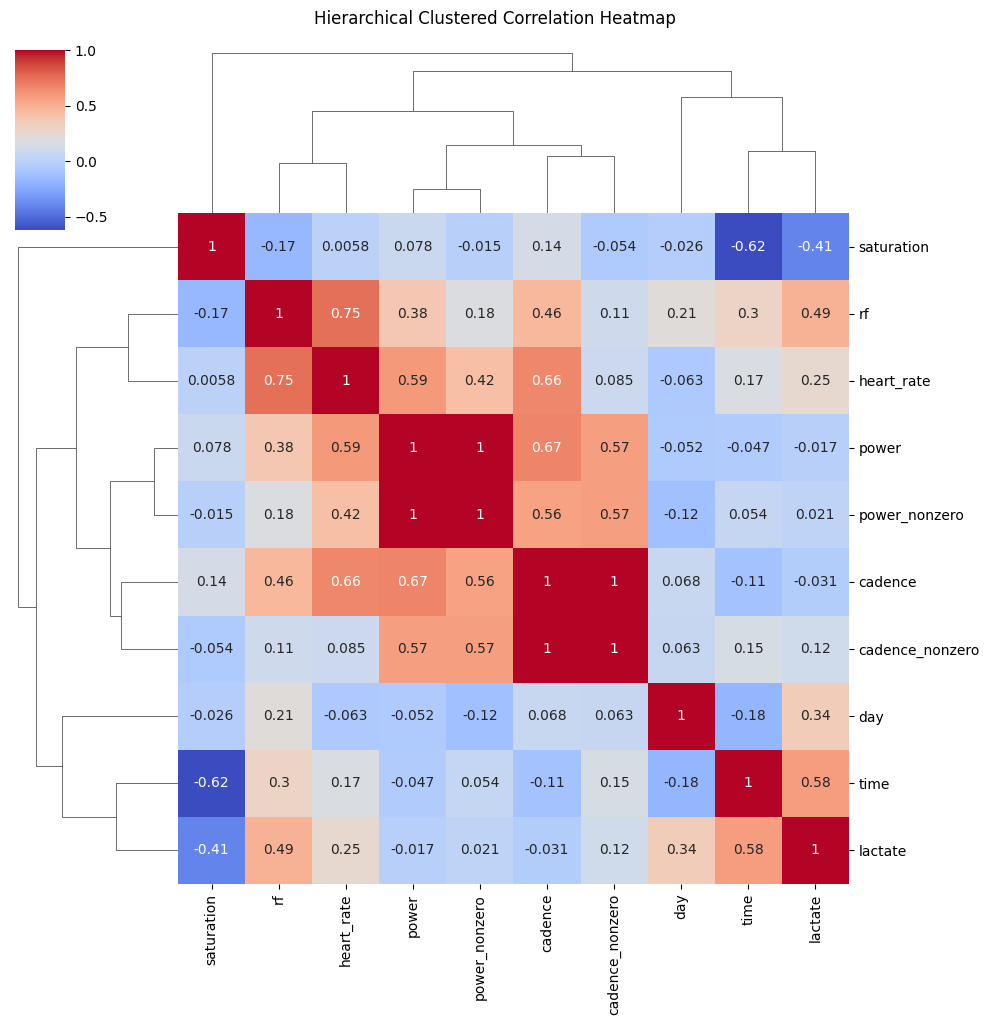

In [128]:
corr = df.corr()

sns.clustermap(corr, cmap="coolwarm", annot=True)

plt.suptitle("Hierarchical Clustered Correlation Heatmap", y=1.02)
plt.show()

The clustermap shows the similar effects of the correlations showed, with 3 distinct clusters:

    - VO2, rf, and heart_rate

    - power, cadence, VO2, and heart rate
    
    - Saturation, lactate, and time


This suggests these features could be collinear, and thus only one of them should be included in the final models. 

### 3.7 - Findings Summary

In summary, we can find strong initial correlations between various features of the dataset which will be useful for constructing a series of regression tests. In addition, we have identified a few notably issues with the dataset, such as discrepencies in correlations between different days of testing, as well as instances of potential collinearity, which will need to be accounted for when evaluating the hypothesis.

## 4 - Baseline Model

For our initial model, we tested the predictive ability of a simple linear regression model by using all potential features individually, and then used the best performing non-collinear features to construct a multiple linear regression model.


### 4.1 - Simple Linear Regression

`test_model` is a function that takes in a feature set of predictors, and a model type, and a response with a default parameter of the target variable. The two sets are split into training  and testing, the model is fit on the training set and then tested on the testing set, and the MSE is returned.

To handle the NaNs from power_nonzero and cadence_nonzero, we took the associated points from `lactate` as `lactate_power_nonzero` and `lactate_cadence_nonzero`. For the sake of future modeling, we may just use `power` and `cadence` as they are to avoid gaps in the data as necesary. We plan to use `power_nonzero` and `cadence_nonzero` **only** when analyzing the effect of removing zeros 

In [129]:
# Library for R2 score
from sklearn.metrics import r2_score


# # subset lactate for nonzero power / cadence
lactate_power_nonzero = df.loc[df["power_nonzero"].notna(), "lactate"]
lactate_cadence_nonzero = df.loc[df["cadence_nonzero"].notna(), "lactate"]

# Drop Time and Day
drop_features = {"time", "day"}

def test_model(X, model, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)

features = []
r2_scores = []

for name, col in df.items():
    if name == "lactate":
        continue  # this is the response

    if name in drop_features:
        continue

    # handle NaNs in power_nonzero
    if name == "power_nonzero":
        mask = df["power_nonzero"].notna()
        X = col[mask].to_frame()
        y = lactate_power_nonzero

    # handle NaNs in cadence_nonzero
    elif name == "cadence_nonzero":
        mask = df["cadence_nonzero"].notna()
        X = col[mask].to_frame()
        y = lactate_cadence_nonzero

    # for all other predictors, use full lactate series
    else:
        mask = (~col.isna()) & (~df["lactate"].isna())
        X = col[mask].to_frame()
        y = df.loc[mask, "lactate"]

    r2 = test_model(X, LinearRegression(), y)
    features.append(name)
    r2_scores.append(r2)

results_df = pd.DataFrame({
    "Feature": features,
    "Linear Regression R^2": r2_scores
}).sort_values(by="Linear Regression R^2", ascending=False)

results_df["Linear Regression R^2"] = results_df["Linear Regression R^2"].astype(float).map("{:.6f}".format)


results_df


,Feature,Linear Regression R^2
2,rf,0.229954
4,saturation,0.181763
3,heart_rate,0.059199
6,power_nonzero,0.000227
1,cadence,0.000089
0,power,0.000052
5,cadence_nonzero,-0.001720


**Conclusion of Simple Linear Regression:** This series of simple linear regressions suggests that `rf` is the strongest single predictor of blood lactate among the variables considered. It has the lowest MSE, which is 8.014. This is consistent with intuition. The data illustrates a physiological progression of an incremental cycling test, where `lactate` accumulates systematically as the test advances. 

heart rate (`heart_rate`) and oxygen saturation (`saturation`) also show moderate explanatory power, indicating that ventilatory and oxygenation dynamics track changes in `lactate` to some extent, though less directly than time itself. 

In contrast, `power` and `cadence` (both raw and nonzero-only forms) perform relatively poorly as standalone predictors. This is likely because their relationship with lactate generally has appeared to be nonlinear through our analysis. It takes time for lactate to build up as th athlete is exerting power on the bike, so the predictors are mediated by accumulated effort rather than instantaneous values. 

It should be noted that `power` and `power_nonzero` (and similarly `cadence` variants) have nearly identical MSEs. This suggests to us that removing zero values alone does not fundamentally improve their predictive value in a univariate setting. Thus, it makes sense to drop the non-zerocolumns as we proceed to further analysis. They were helpful in understanding our data, however, by nature there are gaps and NaN values. This will not be helpful as we move forward into modeling.

In [130]:
df = df.drop(columns=["power_nonzero", "cadence_nonzero"])


### 4.2.5 - Feature Scaling

In prep for more advanced analysis, we are now scaling our features. Note, we did NOT use OneHotEncoder for the categorical features because the days are consecutive and blood oxygen saturation is continuous, even if it looks discrete.

In [131]:
# Separate columns
numeric_cols = df.select_dtypes(include="number").columns.drop("day", "saturation")
categorical_cols = ["day", "saturation"]

numerical_data = df[numeric_cols]
categorical_data = df[categorical_cols]

scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(numerical_data)

scaled_numeric_df = pd.DataFrame(
    scaled_numeric,
    columns=numeric_cols,
    index=df.index
)

scaled_df = pd.concat([scaled_numeric_df, categorical_data], axis=1)

df_day1_scaled = scaled_df[scaled_df["day"] == 1]
df_day2_scaled = scaled_df[scaled_df["day"] == 2]
df_day3_scaled = scaled_df[scaled_df["day"] == 3]

### 4.2 - Multiple Linear Regression
From the initial test, we see that the most predictive features are `rf`,`saturation`, and `heart rate`, with further features having incredibly low predictive power, lower even than the day of the test itself. As a result, these 3 features will be chosen for an initial multiple linear regression.


In [1]:
feature_cols = ["rf", "saturation", "heart_rate"]
X = df[feature_cols]
y = df["lactate"]

# evaluate R^2
multi_lr = LinearRegression()
r2_multi = test_model(X, multi_lr, y)
print("Multivariable Linear Regression R^2 (rf, saturation, heart rate):", r2_multi)

NameError: name 'df' is not defined

The result yields an R^2 of 0.359, higher than the OLS model!

While the multiple regression model performed better, this initial test shows that a simple linear regression model has relatively low predictive power. This suggests that an approach using more complex regressions may be useful for predicting lactate threshold.

Next we will be trying a model with interaction terms. The intuition for this approach is that biometric data has a tendency to have predictors that affect one another. An interaction term may be better able to capture these changes since they demonstrate the change in one variable when another has a one unit increase or decrease.

### 4.3 - Model with Interaction Terms

This code extends the earlier linear regression by adding interaction terms among the predictors. After selecting the three variables of interest (`rf`, `heart_rate`, and `saturation`), the PolynomialFeatures function is used to generate all pairwise products of these variables. 

By setting degree=2 and interaction_only=True we can ensure that only one interaction term is created, and it does not add squared terms for each individual feature. The resulting expanded feature matrix is then split into training and testing sets. 

Upon fitting the model, we found that the resulting R^2 of the interaction model is 0.437. This is lower than the previous models!

In [133]:
from sklearn.preprocessing import PolynomialFeatures

feature_cols = ["rf", "saturation", "heart_rate"]
X = df[feature_cols]
y = df["lactate"]

# interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter = poly.fit_transform(X)

# fit regression
X_train, X_test, y_train, y_test = train_test_split(
    X_inter, y, test_size=0.2, random_state=42
)

model_inter = LinearRegression()
model_inter.fit(X_train, y_train)


r2_inter = test_model(X_inter, model_inter, y)
print("Interaction Model R^2:", r2_inter)

Interaction Model R^2: 0.437326276634306


### 4.4 - Polynomial Term (squared term)

This model extends the basic regression by allowing the predictors to enter the equation non-linearly. PolynomialFeatures constructs a new design matrix containing each original variable, its squared value, and all pairwise products of variables. We chose a second-degree polynomial regression. Thus, we are using a squared term.

Upon fitting the model, we found that the resulting R^2 of the polynomial model is 0.449. Once again, we have a model with a lower R^2 than all of our previous models!

In [134]:
from sklearn.preprocessing import PolynomialFeatures

feature_cols = ["rf", "saturation", "heart_rate"]
X = df[feature_cols]
y = df["lactate"]

# generate polynomial and interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# fit the polynomial regression model
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

# predictions
y_pred = model_poly.predict(X_test)
r2_poly = test_model(X_poly, model_poly, y)

print("Polynomial Model R^2:", r2_poly)

Polynomial Model R^2: 0.44908450728351956


### 4.5 - Model Selection Comparison

The comparison of mean squared error (MSE) across modeling approaches shows a consistent improvement in predictive performance as model complexity increases. The simple linear regression (using only `rf` as a predictor) performs the worst (R^2 = 0.230). This indicates that time alone does not adequately capture variation in the response. Adding additional physiological predictors such as saturation and heart rate does substantially improve accuracy (R^2 = 0.359). This demonstrates that multivariable relationships meaningfully enhance the model. Introducing interaction effects between predictors reduces our mean squared error further (R^2 = 0.437). This suggests synergistic relationships among variables, which intuitively falls in line with biometric data. The best performance we have achieved so far is by the polynomial model (R^2 = 0.449). This indicates a presence of important nonlinear dynamics in the physiological response. Overall, these results show that lactate-related outcomes are best captured by models that incorporate multivariate and nonlinear structure rather than simple linear realtionships with respiratory frequency. Please see the below dataframe for a clear depiction of these results in tabular form.

In [135]:
# R^2 values
results = {
    "Model": [
        "Linear Regression (rf)",
        "Multivariable Linear Regression rf, saturation, heart rate)",
        "Interaction Model",
        "Polynomial Model"
    ],
    "R^2": [
        results_df["Linear Regression R^2"].iloc[0],
        r2_multi,
        r2_inter,
        r2_poly
    ]
}

pd.set_option('display.max_colwidth', None)
df_results = pd.DataFrame(results)
df_results


,Model,R^2
0,Linear Regression (rf),0.229954
1,"Multivariable Linear Regression rf, saturation, heart rate)",0.359
2,Interaction Model,0.437
3,Polynomial Model,0.449


#### 4.5.1 - Assumption Checking for Linear Models

1. Fit the OLS linear model

**QUESTION: How do I handle NaNs from power_nonzero in this OLS? Do I just drop the nonzero columns and base my model on the data with 0's?**

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

y = df["lactate"]

X = df.drop(columns=["lactate", "day", "time"])

X = sm.add_constant(X)

# Fit
model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

# Extract fitted values & residuals
fitted = model.fittedvalues
residuals = model.resid

                            OLS Regression Results                            
Dep. Variable:                lactate   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     1174.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:32:17   Log-Likelihood:                -20559.
No. Observations:                8818   AIC:                         4.113e+04
Df Residuals:                    8812   BIC:                         4.117e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.3701      1.643     31.882      0.0

**2. Predictor Distributions (look for Normality / Skewness)**

We printed these before but we are printing them again so it is in the same section.

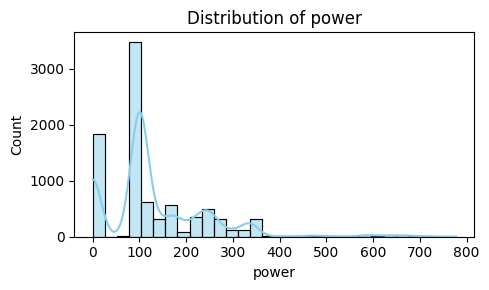

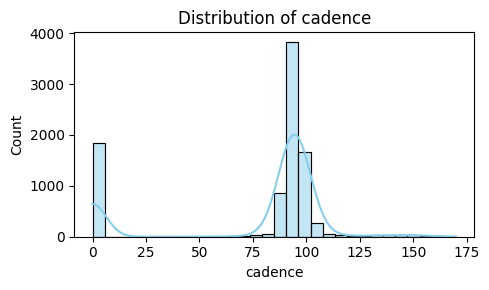

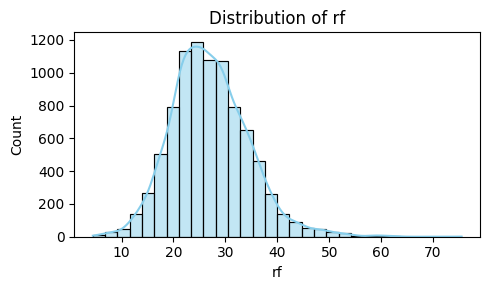

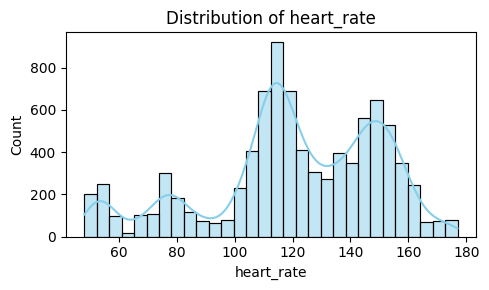

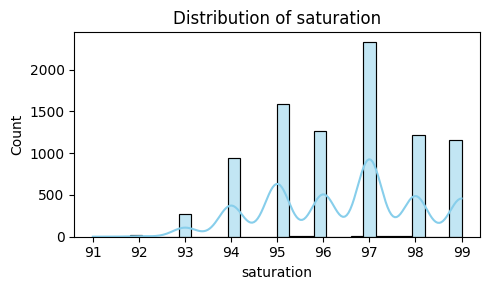

In [137]:
for col in X.columns:
    if col == "const":
        continue
    plt.figure(figsize=(5, 3))
    sns.histplot(X[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

**3. Linearity & Homoscedasticity — Residuals vs Fitted**

Our response is bounded. The bottom left "line" in the graph that runs from (0,2) to (4,-4) represents the lower bound, then the "line" that is in the most top-right part of the graph represents the outer bound.

Because our response is bounded, this residuals vs fitted makes sense.


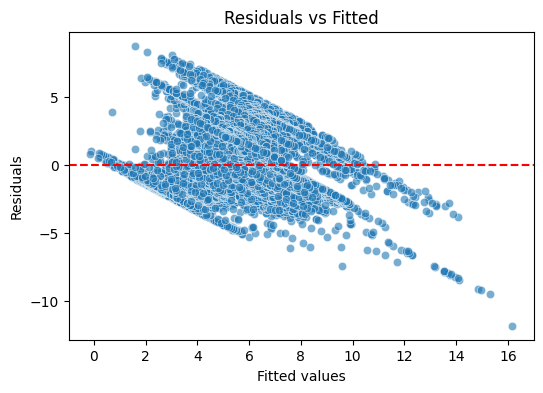

In [138]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

**4. Normality of Residuals — Q-Q Plot**

Generally the normality assumption is upheld with some slight deviation at the top left tail.

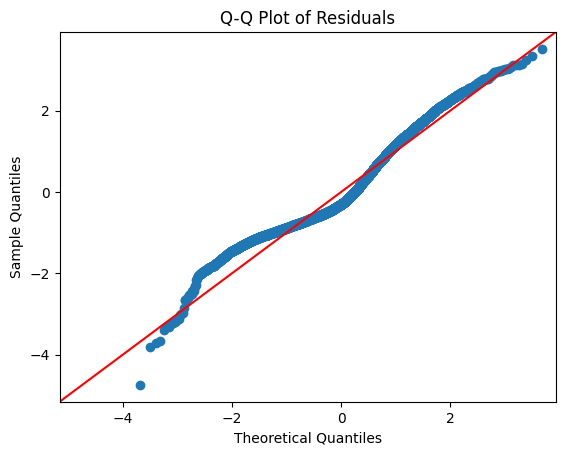

Shapiro-Wilk p-value: 2.2162708198699497e-48


C:\Users\sburg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8818.
  res = hypotest_fun_out(*samples, **kwds)


In [139]:
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro–Wilk Test for Normaility as well -- p > 0.5 is usually good
stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)


**5. Residual Histogram**

The histogram of residuals looks good!

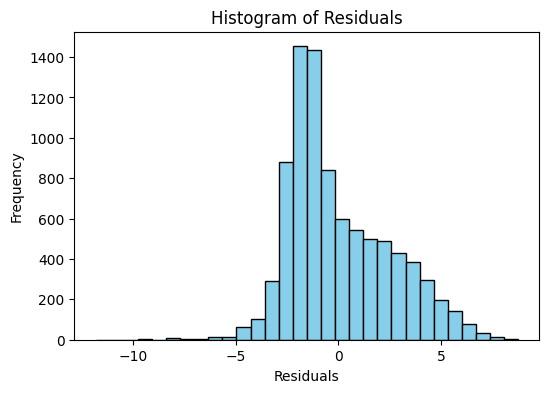

In [140]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()


## 5 - Predictions


Returning the lowest MSE, let's use the polynomial regression above as our baseline model for ridge and lasso. 

In [45]:
# Add to imports in section 2.1 (if not already there)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, GridSearchCV, KFold

### 5.1 - Standard (OLS) Multiple Linear Regression

In [46]:
# Prepare features and target
X = df.drop(['lactate', 'time', 'day'], axis=1)  # Remove lactate (target) and time
y = df['lactate']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Baseline Linear Model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Cross-validation score
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(baseline_model, X, y, cv=tscv, scoring='r2')
y_pred_baseline = baseline_model.predict(X)

print(f"Training R²: {baseline_model.score(X_train, y_train):.4f}")
print(f"Test R²: {baseline_model.score(X_test, y_test):.4f}")
print(f"Cross-validation R² (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Training R²: 0.3998
Test R²: 0.3997
Cross-validation R² (5-fold): -4.3688 (+/- 14.9198)


### 5.2 - LASSO

In [47]:
# LASSO Regression 
alphas = np.logspace(-4, 1, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42, n_jobs=-1)

# Fit the model
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X)

print(f"Best alpha from cross-validation: {lasso_cv.alpha_:.6f}")
print(f"Training R²: {lasso_cv.score(X_train, y_train):.4f}")
print(f"Test R²: {lasso_cv.score(X_test, y_test):.4f}")
print(f"Number of features used: {np.sum(lasso_cv.coef_ != 0)}")

# Display feature importance
feature_importance_lasso = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso_cv.coef_,
    'abs_coefficient': np.abs(lasso_cv.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 5 most important features (LASSO):")
print(feature_importance_lasso.head(5).to_string(index=False))

Best alpha from cross-validation: 0.000100
Training R²: 0.3998
Test R²: 0.3997
Number of features used: 5

Top 5 most important features (LASSO):
   feature  coefficient  abs_coefficient
saturation       -0.535            0.535
        rf        0.237            0.237
   cadence       -0.018            0.018
heart_rate        0.004            0.004
     power       -0.002            0.002


### 5.3 - RIDGE

In [48]:
# RIDGE Regression 
ridge_cv = RidgeCV(alphas=alphas, cv=5)

# Fit the model
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X)

print(f"Best alpha from cross-validation: {ridge_cv.alpha_:.6f}")
print(f"Training R²: {ridge_cv.score(X_train, y_train):.4f}")
print(f"Test R²: {ridge_cv.score(X_test, y_test):.4f}")

# Display feature importance for ridge
feature_importance_ridge = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ridge_cv.coef_,
    'abs_coefficient': np.abs(ridge_cv.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 5 most important features (RIDGE):")
print(feature_importance_ridge.head(5).to_string(index=False))


Best alpha from cross-validation: 0.000100
Training R²: 0.3998
Test R²: 0.3997

Top 5 most important features (RIDGE):
   feature  coefficient  abs_coefficient
saturation       -0.535            0.535
        rf        0.237            0.237
   cadence       -0.018            0.018
heart_rate        0.004            0.004
     power       -0.002            0.002


### 5.4 - Polynomial

In [49]:
# Polynomial Regression
# Try different polynomial degrees
degrees = [2, 3, 4, 5]
best_poly_score = -np.inf
best_poly_degree = 2
best_poly_model = None
y_pred_poly_best = None

poly_results = []

for degree in degrees:
    print(f"\nTesting polynomial degree {degree}:")
    
    # Create polynomial features pipeline
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression())
    ])
    
    # Fit the model
    poly_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_poly = poly_model.predict(X)
    
    # Calculate scores
    train_score = poly_model.score(X_train, y_train)
    test_score = poly_model.score(X_test, y_test)
    
    print(f"  Training R²: {train_score:.4f}")
    print(f"  Test R²: {test_score:.4f}")
    
    # Cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores_poly = cross_val_score(poly_model, X, y, cv=tscv, scoring='r2')
    print(f"  Cross-validation R² (5-fold): {cv_scores_poly.mean():.4f} (+/- {cv_scores_poly.std() * 2:.4f})")
    
    poly_results.append({
        'degree': degree,
        'train_score': train_score,
        'test_score': test_score,
        'cv_score': cv_scores_poly.mean(),
        'n_features': poly_model.named_steps['poly'].n_output_features_
    })
    
    # Track best model
    if test_score > best_poly_score:
        best_poly_score = test_score
        best_poly_degree = degree
        best_poly_model = poly_model
        y_pred_poly_best = y_pred_poly

print(f"\nBest polynomial degree: {best_poly_degree} with test R²: {best_poly_score:.4f}")
print(f"Number of polynomial features created: {best_poly_model.named_steps['poly'].n_output_features_}")


Testing polynomial degree 2:
  Training R²: 0.5724
  Test R²: 0.5872
  Cross-validation R² (5-fold): -4.2104 (+/- 14.0024)

Testing polynomial degree 3:
  Training R²: 0.6741
  Test R²: 0.6667
  Cross-validation R² (5-fold): -7.0891 (+/- 13.7372)

Testing polynomial degree 4:
  Training R²: 0.7170
  Test R²: 0.6980
  Cross-validation R² (5-fold): -56.1872 (+/- 99.8689)

Testing polynomial degree 5:
  Training R²: 0.7475
  Test R²: -0.6153
  Cross-validation R² (5-fold): -5548.7434 (+/- 15288.4442)

Best polynomial degree: 4 with test R²: 0.6980
Number of polynomial features created: 125


### 5.5 - Random Forest

In [50]:
# Random Forest Regression
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Define parameter grid for grid search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Use GridSearchCV for hyperparameter tuning
rf_grid = GridSearchCV(
    rf_model, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

# Fit the model
rf_grid.fit(X_train, y_train)
y_pred_rf = rf_grid.predict(X)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")
print(f"Training R²: {rf_grid.score(X_train, y_train):.4f}")
print(f"Test R²: {rf_grid.score(X_test, y_test):.4f}")

# Get feature importance from Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 most important features (Random Forest):")
print(feature_importance_rf.head(5).to_string(index=False))

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.9287
Training R²: 0.9913
Test R²: 0.9386

Top 5 most important features (Random Forest):
   feature  importance
saturation       0.265
        rf       0.244
     power       0.242
heart_rate       0.193
   cadence       0.057


### 5.6 - Gradient Boosting

Generally, Gradient Boosting outperforms Random Forest.

In [51]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Base model with fixed tree / subsample settings
gbr = GradientBoostingRegressor(
    random_state=42,
    subsample=0.8,
)

# Hyperparameter grid
param_grid_gbr = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [5, 10, 20]
}

gbr_grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    scoring="r2",
    cv=3,                 # or your GroupKFold / LeaveOneGroupOut here
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

# Fit on training data
gbr_grid.fit(X_train, y_train)

# Best model from grid search
best_gbr = gbr_grid.best_estimator_

# Predictions
gbr_pred_train = best_gbr.predict(X_train)
gbr_pred_test = best_gbr.predict(X_test)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


In [52]:
# Results
print("Best parameters:", gbr_grid.best_params_)
print(f"Best CV R²: {gbr_grid.best_score_:.4f}")

gbr_train_r2 = best_gbr.score(X_train, y_train)
print(f"Training R²: {best_gbr.score(X_train, y_train):.4f}")

gbr_test_r2 = best_gbr.score(X_test, y_test)
print(f"Test R²: {best_gbr.score(X_test, y_test):.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 800, 'subsample': 0.8}
Best CV R²: 0.9068
Training R²: 0.9447
Test R²: 0.9102


### 5.7 - Mixture of Experts

We defined my own Mixture of Experts model. This was unbelievably difficult to code.

In [53]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.utils.validation import check_is_fitted

class RFMixtureOfExperts(BaseEstimator, RegressorMixin):

    # inherit from BaseEstimator to tune hyperparameters later using GridSearchCV
    # inherit from RegressorMixin b/c it adds a score method

    # init default values
    def __init__(
        self,
        n_experts=3,
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
    ):

    # but also set these features; basically all from random_forest besides the "n_experts"
        self.n_experts = n_experts
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    ################
    # FIT FUNCTION #
    ################
    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        # this is the gating function
        self.kmeans_ = KMeans(
            n_clusters=self.n_experts,
            random_state=self.random_state,
            n_init="auto"
        )
        cluster_labels = self.kmeans_.fit_predict(X)

        # for each cluster defined, we train an expert
        self.experts_ = []
        for k in range(self.n_experts):
            idx = np.where(cluster_labels == k)[0]
            X_k, y_k = X[idx], y[idx]   # <— define cluster data
        
            rf = RandomForestRegressor(
                n_estimators=self.n_estimators,
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state + k,
                n_jobs=-1
            )
            rf.fit(X_k, y_k)
            self.experts_.append(rf)

        return self

    ####################
    # PREDICT FUNCTION #
    ####################
    
    def predict(self, X):
        check_is_fitted(self, ["kmeans_", "experts_"])
        X = np.asarray(X)

        # figure out what cluster a particular sample is in
        cluster_pred = self.kmeans_.predict(X)

        # now predict it
        y_pred = np.zeros(X.shape[0], dtype=float)
        for k, expert in enumerate(self.experts_):
            idx = np.where(cluster_pred == k)[0]
            if len(idx) > 0:
                y_pred[idx] = expert.predict(X[idx])

        return y_pred

Now, we apply the MOE model and get the R2.

In [54]:
moe_rf = RFMixtureOfExperts(
    n_experts=3,          # try 2–4
    n_estimators=200,     # like your RF grid
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

moe_rf.fit(X_train, y_train)

y_pred_train_moe = moe_rf.predict(X_train)
y_pred_test_moe  = moe_rf.predict(X_test)

print(f"MoE RF Train R²: {r2_score(y_train, y_pred_train_moe) :.4f}")
print(f"MoE RF Test  R²: {r2_score(y_test,  y_pred_test_moe) :.4f}")

MoE RF Train R²: 0.9915
MoE RF Test  R²: 0.9396


I'm curious as to what the gating function actually does.

In [55]:
def summarize_gating(model, X, feature_names):
    X = np.asarray(X)
    centers = model.kmeans_.cluster_centers_
    centers_df = pd.DataFrame(centers, columns=feature_names)
    centers_df.index = [f"Expert {k}" for k in range(model.n_experts)]
    return centers_df

def expert_counts(model, X):
    X = np.asarray(X)
    cluster_labels = model.kmeans_.predict(X)
    counts = pd.Series(cluster_labels).value_counts().sort_index()
    counts.index = [f"Expert {k}" for k in counts.index]
    return counts

print("Relevant Features")
print(summarize_gating(moe_rf, X_train, X_train.columns))

print("\nNumber of Samples in Each Cluster")
print(expert_counts(moe_rf, X_train))

Relevant Features
            power  cadence      rf  heart_rate  saturation
Expert 0  153.329   94.679  28.695     130.564      96.581
Expert 1    0.253    0.046  20.486      82.701      95.916
Expert 2  578.233  137.113  32.556     136.349      96.333

Number of Samples in Each Cluster
Expert 0    5447
Expert 1    1448
Expert 2     159
Name: count, dtype: int64


Now, we will tune the hyperparameters.

In [56]:
moe_rf = RFMixtureOfExperts(random_state=42)

# copied from my RF param grid earlier
param_grid_moe = {
    "n_experts": [2, 3, 4],
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5],
}

# hyperparameter tuning
moe_grid = GridSearchCV(
    estimator=moe_rf,
    param_grid=param_grid_moe,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
moe_grid.fit(X_train, y_train)
best_moe_rf = moe_grid.best_estimator_
print("Best MoE RF params:", moe_grid.best_params_)

# R2 Results
moe_train_r2 = r2_score(y_train, best_moe_rf.predict(X_train))
moe_test_r2  = r2_score(y_test,  best_moe_rf.predict(X_test))

print(f"Best MoE RF CV R²: {moe_grid.best_score_:.4f}")
print(f"MoE RF Train R²:   {moe_train_r2:.4f}")
print(f"MoE RF Test R²:    {moe_test_r2:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best MoE RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'n_experts': 3}
Best MoE RF CV R²: 0.9291
MoE RF Train R²:   0.9914
MoE RF Test R²:    0.9392


In [57]:
print("Relevant Features")
print(summarize_gating(best_moe_rf, X_train, X_train.columns))

print("\nNumber of Samples in Each Cluster")
print(expert_counts(best_moe_rf, X_train))

Relevant Features
            power  cadence      rf  heart_rate  saturation
Expert 0  153.329   94.679  28.695     130.564      96.581
Expert 1    0.253    0.046  20.486      82.701      95.916
Expert 2  578.233  137.113  32.556     136.349      96.333

Number of Samples in Each Cluster
Expert 0    5447
Expert 1    1448
Expert 2     159
Name: count, dtype: int64


### 5.8 - Model Comparisons

In [58]:
# Create comparison dataframe
comparison_data = {
    'Model': [
        'Baseline Linear', 
        'LASSO CV', 
        'RIDGE CV', 
        f'Polynomial (deg={best_poly_degree})', 
        'Random Forest',
        'Gradient Boosting',
        'Mixture of Experts'
    ],
    'Train R²': [
        baseline_model.score(X_train, y_train),
        lasso_cv.score(X_train, y_train),
        ridge_cv.score(X_train, y_train),
        best_poly_model.score(X_train, y_train),
        rf_grid.best_estimator_.score(X_train, y_train),
        gbr_train_r2,
        moe_train_r2
    ],
    'Test R²': [
        baseline_model.score(X_test, y_test),
        lasso_cv.score(X_test, y_test),
        ridge_cv.score(X_test, y_test),
        best_poly_score,
        rf_grid.best_estimator_.score(X_test, y_test),
        gbr_test_r2,
        moe_test_r2    # fixed typo
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Determine best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_score = comparison_df.loc[best_model_idx, 'Test R²']

print(f"\nBest performing model: {best_model_name} with Test R² = {best_model_score:.4f}")

             Model  Train R²  Test R²
   Baseline Linear     0.400    0.400
          LASSO CV     0.400    0.400
          RIDGE CV     0.400    0.400
Polynomial (deg=4)     0.717    0.698
     Random Forest     0.991    0.939
 Gradient Boosting     0.945    0.910
Mixture of Experts     0.991    0.939

Best performing model: Mixture of Experts with Test R² = 0.9392


In [59]:
# Create comparison dataframe
comparison_data = {
    'Model': [
        'Baseline Linear', 
        'LASSO CV', 
        'RIDGE CV', 
        f'Polynomial (deg={best_poly_degree})', 
        'Random Forest',
        'Gradient Boosting',
        'Mixture of Experts'
    ],
    'Train R²': [
        baseline_model.score(X_train, y_train),
        lasso_cv.score(X_train, y_train),
        ridge_cv.score(X_train, y_train),
        best_poly_model.score(X_train, y_train),
        rf_grid.best_estimator_.score(X_train, y_train),
        gbr_train_r2,
        moe_train_r2
    ],
    'Test R²': [
        baseline_model.score(X_test, y_test),
        lasso_cv.score(X_test, y_test),
        ridge_cv.score(X_test, y_test),
        best_poly_score,
        rf_grid.best_estimator_.score(X_test, y_test),
        gbr_test_r2,
        moe_test_r2    # fixed typo
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Determine best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_score = comparison_df.loc[best_model_idx, 'Test R²']

print(f"\nBest performing model: {best_model_name} with Test R² = {best_model_score:.4f}")

             Model  Train R²  Test R²
   Baseline Linear     0.400    0.400
          LASSO CV     0.400    0.400
          RIDGE CV     0.400    0.400
Polynomial (deg=4)     0.717    0.698
     Random Forest     0.991    0.939
 Gradient Boosting     0.945    0.910
Mixture of Experts     0.991    0.939

Best performing model: Mixture of Experts with Test R² = 0.9392


In [60]:
# Create comparison dataframe
comparison_data = {
    'Model': [
        'Baseline Linear', 
        'LASSO CV', 
        'RIDGE CV', 
        f'Polynomial (deg={best_poly_degree})', 
        'Random Forest',
        'Gradient Boosting',
        'Mixture of Experts',
    ],
    'Train R²': [
        baseline_model.score(X_train, y_train),
        lasso_cv.score(X_train, y_train),
        ridge_cv.score(X_train, y_train),
        best_poly_model.score(X_train, y_train),
        rf_grid.score(X_train, y_train),
        rf_grid.score(X_train, y_train),
        rf_grid.score(X_train, y_train),
        gbr_train_r2,
        moe_train_r2,
    ],
    'Test R²': [
        baseline_model.score(X_test, y_test),
        lasso_cv.score(X_test, y_test),
        ridge_cv.score(X_test, y_test),
        best_poly_score,
        rf_grid.score(X_test, y_test),
        gbr_test_r2,
        moe_text_r2
    ]
    '''
    'Features Used': [
        X.shape[1],
        np.sum(lasso_cv.coef_ != 0),
        X.shape[1],
        best_poly_model.named_steps['poly'].n_output_features_,
        X.shape[1],
        "",
        ""
    ]
    'Regularization': ['None', f'α={lasso_cv.alpha_:.4f}', f'α={ridge_cv.alpha_:.4f}', 'None', 'Tree-based']
    '''
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Determine best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_score = comparison_df.loc[best_model_idx, 'Test R²']

print(f"\nBest performing model: {best_model_name} with Test R² = {best_model_score:.4f}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (512391526.py, line 23)

## 6 - Bayes Hier.

The `Random Forest` model in `Section 5.5` was one of our best performing models. This model marked `saturation` as our most important feature (with a value of 0.265). To further explore this variable, we fit a Bayesian hierarchical linear model predicting lactate as a function of oxygen saturation. Because it looks like the athlete did different pieces at heart rate (e.g. three long pieces in the first day but bursts on the third day), we took both intercepts and slopes varying by day. This structure is helpful it allows each training day to have its own baseline lactate level and its own sensitivity of lactate to saturation. 

It still shares information across days through group-level priors. The results indicate meaningful intra-day differences in baseline lactate levels. Additinally, there are consistently negative saturation x lactate relationships across all days. The hierarchical formulation appears to improve stability and interpretability relative to fitting separate models per day by borrowing strength across groups, while explicitly quantifying uncertainty and intra-day variability in the regression coefficients.

In [ ]:
import numpy as np
import arviz as az
import pymc as pm

# number of groups 
n_days = df["day"].nunique() 
# day index per row: {0,1,2} 
day_idx = df["day"].values.astype(int) - 1 

sat = df["saturation"].values 
lactate = df["lactate"].values 

with pm.Model() as hierarchical_model: 
    # Hyperpriors for intercepts 
    mu_a = pm.Normal('b0_mu', mu=0., sigma=100.) 
    sigma_a = pm.HalfNormal('b0_sigma', 5.) 
    
    # Hyperpriors for slopes 
    mu_b = pm.Normal('b1_mu', mu=0., sigma=100.) 
    sigma_b = pm.HalfNormal('b1_sigma', 5.) 
    
    # Day-specific intercepts and slopes 
    a = pm.Normal('b0', mu=mu_a, sigma=sigma_a, shape=n_days) # (3,) 
    b = pm.Normal('b1', mu=mu_b, sigma=sigma_b, shape=n_days) # (3,) 
    
    # Linear predictor for each observation 
    y_mu = a[day_idx] + b[day_idx] * sat 
    
    # Observation noise 
    sigma = pm.HalfNormal('sigma', 5.) 
    
    # Likelihood 
    y = pm.Normal('y', mu=y_mu, sigma=sigma, observed=lactate) 

with hierarchical_model:
    trace = pm.sample(
        draws=500,
        tune=500,
        target_accept=0.9,
        cores=1,
        random_seed=42,
    )

In [ ]:
pm.plot_trace(trace, var_names=['b0_mu', 'b1_mu',
                                            'b0_sigma', 'b1_sigma'])
plt.tight_layout();

results = pm.summary(trace)
results[:10]

In [ ]:
with hierarchical_model:
    ppc = pm.sample_posterior_predictive(trace)

# Extract y predictions
y_ppc = ppc.posterior_predictive["y"].values    # shape (chains, draws, n_obs)

# Collapse chains + draws to get posterior predictive samples
y_ppc = y_ppc.reshape(-1, y_ppc.shape[-1])      # (all_samples, n_obs)

# Posterior predictive mean
y_hat = y_ppc.mean(axis=0)

# Compute R²
y_true = lactate

ss_res = np.sum((y_true - y_hat) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Bayesian posterior predictive R²: {r2:.4f}")


In [ ]:
pm.plot_posterior(trace, var_names=['b1']);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

days = np.sort(df["day"].unique())
n_days = len(days)

# grid of saturation values for drawing the fitted lines
sat_min, sat_max = df["saturation"].min(), df["saturation"].max()
xx = np.linspace(sat_min, sat_max, 100)

# posterior means (of day-specific intercepts and slopes)
b0_mean = trace.posterior["b0"].mean(dim=("chain", "draw")).values  # shape (n_days,)
b1_mean = trace.posterior["b1"].mean(dim=("chain", "draw")).values  # shape (n_days,)

fig, axs = plt.subplots(1, n_days, figsize=(5 * n_days, 4), sharey=True)

for i, day in enumerate(days):
    ax = axs[i]

    # data for this day
    mask = df["day"] == day
    sat_day = df.loc[mask, "saturation"]
    lact_day = df.loc[mask, "lactate"]

    # scatter of observed data
    ax.scatter(sat_day, lact_day, alpha=0.3, label=f"Day {day} data")

    # hierarchical fitted line for this day
    y_hat_hier = b0_mean[i] + b1_mean[i] * xx
    ax.plot(xx, y_hat_hier, c="teal", ls=":", label="Hierarchical fit")

    ax.set_xlabel("Saturation")
    if i == 0:
        ax.set_ylabel("Lactate")
    ax.set_title(f"Day {day}")
    ax.legend()

plt.tight_layout()
plt.show()


A forest plot visualizes posterior estimates and their uncertainty, displaying point estimates alongside credible intervals. In hierarchical models, it can illustrate how estimates vary across groups, with shrinkage effects evident when estimates shift toward the overall mean.

In [ ]:
# Forest plot

fig, axs = plt.subplots(1,2, figsize=(12, 20))
az.plot_forest(trace, var_names=['b0'], ax=axs[0])
az.plot_forest(trace, var_names=['b1'], ax=axs[1]);